# Classification Experiments

**Testing:**
1. Does biomass signal growth environment? (Single classfier to split all)
    * Testing if log, raw or L2 provides best signal
    * Testing with and without residuals
    * Testing different prediction of different lables: source, o2-content etc.
2. MultiOutputClassifier -> to evaluate the possibility for a hurdle model

In [41]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import plotly.express as px

In [148]:
# from xgboost import XGBRegressor, XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

# Loss metric:
from sklearn.metrics import mean_squared_error as mse

# evaluation:
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import confusion_matrix, accuracy_score, multilabel_confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

# data prep and plotting etc:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

### Load Data:

In [302]:
train_data = pd.read_pickle(DATA/"ml_datasets/TRAIN_raw.pkl")

log_features = pd.read_pickle(DATA/"ml_datasets/FEATURE_TRAIN.pkl")
l2_features = pd.read_pickle(DATA/"ml_datasets/L2_FEATURES_ML.pkl")

target = train_data[['source', 'source_shadow', 'o2_e_shadow']]
rxn_cols = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e','EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']
target[rxn_cols] = - train_data[rxn_cols]

**for å teste raw signals:**

In [207]:
# raw_features = train_data[['protein_biomass_to_biomass', 'DNA_biomass_to_biomass','ncRNA_biomass_to_biomass', 'prosthetic_group_biomass_to_biomass']]

# log_features.columns.tolist()
# rna_cols = train_data['mRNA_biomass_to_biomass'] + train_data['rRNA_biomass_to_biomass'] + train_data['tRNA_biomass_to_biomass']
# raw_features.insert(1, 'RNA_biomass_to_biomass', rna_cols)
# residuals=log_features.iloc[:, -2:]
# raw_features[residuals.columns.tolist()] = residuals[residuals.columns.tolist()]
# raw_features['ncRNA/RNA'] = raw_features['ncRNA_biomass_to_biomass']/raw_features['RNA_biomass_to_biomass']
# raw_features['protein/DNA'] = raw_features['protein_biomass_to_biomass']/raw_features['protein_biomass_to_biomass']


# ##################################################
# l2_raw = raw_features[['protein_biomass_to_biomass', 'DNA_biomass_to_biomass','ncRNA_biomass_to_biomass', 'prosthetic_group_biomass_to_biomass']]
# from sklearn.preprocessing import Normalizer
# l2_normalizer = Normalizer(norm='l2')
# norm_map = l2_normalizer.transform(l2_raw)

# final_map_df = pd.DataFrame(
#     norm_map, 
#     columns=l2_raw.columns, 
#     index=l2_raw.index
# )

# print("Row norms check (should all be 1.0):")
# print((final_map_df**2).sum(axis=1).head())

# l2_raw_features = final_map_df.copy()
# l2_raw_features[['ncRNA/RNA','protein/DNA','protein_biomass_to_biomass_resid','lipid_biomass_to_biomass_resid']] = raw_features[['ncRNA/RNA','protein/DNA','protein_biomass_to_biomass_resid','lipid_biomass_to_biomass_resid']]

**Splitting training data into train and validation:**

In [303]:
# X = log_features.copy()
X = l2_features.copy() # THE BEST
# X = raw_features.copy()
# X = l2_raw.copy()

Y = target.copy()

In [304]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['source'])

* så blir samme split hver gang!

In [133]:
# Y_val['source'].value_counts()

**Setting up baseline model**

* if class_weight=balanced i have to specify weight for each class in multioutput

In [134]:
base_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

multi_clf = MultiOutputClassifier(base_clf)

## 1. Assessing the overall signal

### 1.1 - Comparing different feature representations:

**Log raw**

In [152]:
Y_train_1 = Y_train['source']
Y_val_1 = Y_val['source']

le_source = LabelEncoder()
Y_train_source = le_source.fit_transform(Y_train_1)
Y_val_source = le_source.transform(Y_val_1)

In [153]:
base_clf.fit(X_train, Y_train_source)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

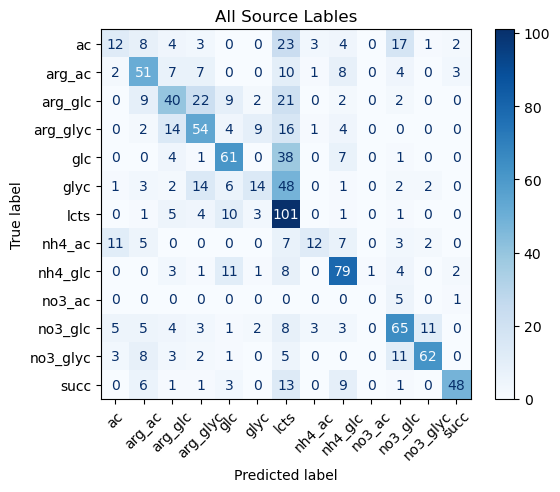

In [154]:
Y_pred_val = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_source, Y_pred_val)
disp = ConfusionMatrixDisplay(cm, display_labels=le_source.classes_)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("All Source Lables")
plt.show()

In [155]:
print(classification_report(
    Y_val_source,
    Y_pred_val,
    target_names=le_source.classes_
))

              precision    recall  f1-score   support

          ac       0.35      0.16      0.22        77
      arg_ac       0.52      0.55      0.53        93
     arg_glc       0.46      0.37      0.41       107
    arg_glyc       0.48      0.52      0.50       104
         glc       0.58      0.54      0.56       112
        glyc       0.45      0.15      0.23        93
        lcts       0.34      0.80      0.48       126
      nh4_ac       0.60      0.26      0.36        47
     nh4_glc       0.63      0.72      0.67       110
      no3_ac       0.00      0.00      0.00         6
     no3_glc       0.56      0.59      0.58       110
    no3_glyc       0.79      0.65      0.72        95
        succ       0.86      0.59      0.70        82

    accuracy                           0.52      1162
   macro avg       0.51      0.45      0.46      1162
weighted avg       0.54      0.52      0.50      1162



In [171]:
Y_train_2 = Y_train['source'].str.split('_').str[0]
Y_val_2 = Y_val['source'].str.split('_').str[0]

le_source2 = LabelEncoder()

Y_train_source2 = le_source2.fit_transform(Y_train_2)
Y_val_source2 = le_source2.transform(Y_val_2)

In [172]:
base_clf.fit(X_train, Y_train_source2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

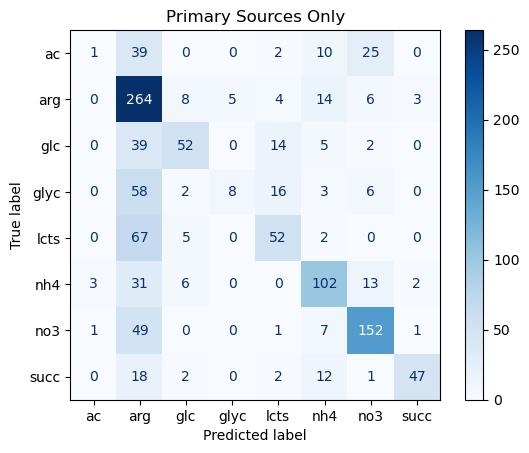

In [173]:
Y_pred_val_2 = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_source2, Y_pred_val_2)
disp = ConfusionMatrixDisplay(cm, display_labels=le_source2.classes_)

disp.plot(cmap='Blues')
plt.title("Primary Sources Only")
plt.show()

* at ac og no3 blandes er litt rart i og med at ingen av no3_ac samplesene er med

In [175]:
print(classification_report(
    Y_val_source2,
    Y_pred_val_2,
    target_names=le_source2.classes_
))

              precision    recall  f1-score   support

          ac       0.20      0.01      0.02        77
         arg       0.47      0.87      0.61       304
         glc       0.69      0.46      0.56       112
        glyc       0.62      0.09      0.15        93
        lcts       0.57      0.41      0.48       126
         nh4       0.66      0.65      0.65       157
         no3       0.74      0.72      0.73       211
        succ       0.89      0.57      0.70        82

    accuracy                           0.58      1162
   macro avg       0.60      0.47      0.49      1162
weighted avg       0.60      0.58      0.55      1162



**L2-norm**

In [158]:
Y_train_1 = Y_train['source']
Y_val_1 = Y_val['source']

le_source = LabelEncoder()
Y_train_source = le_source.fit_transform(Y_train_1)
Y_val_source = le_source.transform(Y_val_1)

In [159]:
base_clf.fit(X_train, Y_train_source)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

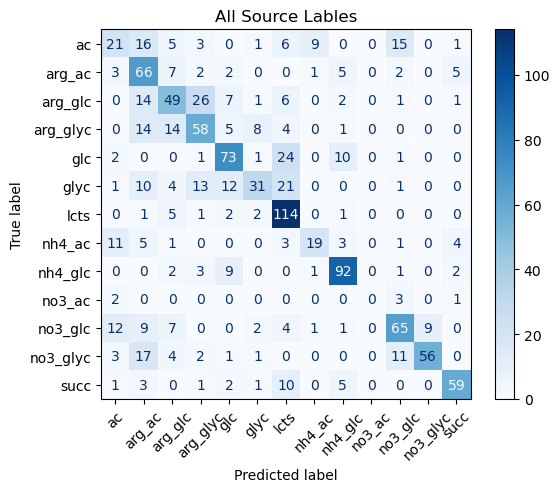

In [160]:
Y_pred_val = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_source, Y_pred_val)
disp = ConfusionMatrixDisplay(cm, display_labels=le_source.classes_)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("All Source Lables")
plt.show()

In [164]:
print(classification_report(
    Y_val_source,
    Y_pred_val,
    target_names=le_source.classes_
))

              precision    recall  f1-score   support

          ac       0.38      0.27      0.32        77
      arg_ac       0.43      0.71      0.53        93
     arg_glc       0.50      0.46      0.48       107
    arg_glyc       0.53      0.56      0.54       104
         glc       0.65      0.65      0.65       112
        glyc       0.65      0.33      0.44        93
        lcts       0.59      0.90      0.72       126
      nh4_ac       0.61      0.40      0.49        47
     nh4_glc       0.77      0.84      0.80       110
      no3_ac       0.00      0.00      0.00         6
     no3_glc       0.64      0.59      0.62       110
    no3_glyc       0.86      0.59      0.70        95
        succ       0.81      0.72      0.76        82

    accuracy                           0.60      1162
   macro avg       0.57      0.54      0.54      1162
weighted avg       0.62      0.60      0.60      1162



/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [203]:
Y_train_2 = Y_train['source'].str.split('_').str[0]
Y_val_2 = Y_val['source'].str.split('_').str[0]

le_source2 = LabelEncoder()

Y_train_source2 = le_source2.fit_transform(Y_train_2)
Y_val_source2 = le_source2.transform(Y_val_2)

In [204]:
base_clf.fit(X_train, Y_train_source2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

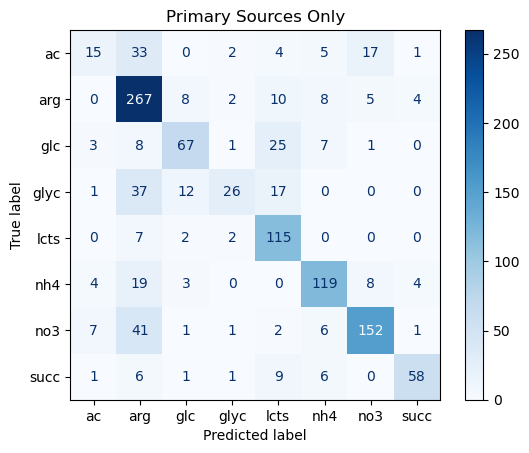

In [167]:
Y_pred_val_2 = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_source2, Y_pred_val_2)
disp = ConfusionMatrixDisplay(cm, display_labels=le_source2.classes_)

disp.plot(cmap='Blues')
plt.title("Primary Sources Only")
plt.show()

In [168]:
print(classification_report(
    Y_val_source2,
    Y_pred_val_2,
    target_names=le_source2.classes_
))

              precision    recall  f1-score   support

          ac       0.48      0.19      0.28        77
         arg       0.64      0.88      0.74       304
         glc       0.71      0.60      0.65       112
        glyc       0.74      0.28      0.41        93
        lcts       0.63      0.91      0.75       126
         nh4       0.79      0.76      0.77       157
         no3       0.83      0.72      0.77       211
        succ       0.85      0.71      0.77        82

    accuracy                           0.70      1162
   macro avg       0.71      0.63      0.64      1162
weighted avg       0.71      0.70      0.69      1162



**RAW FEATURES:**

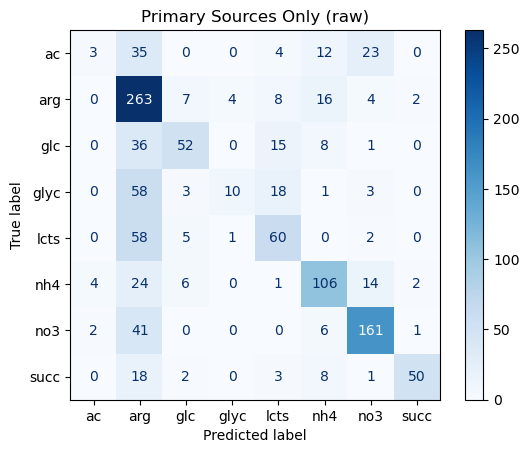

In [195]:
Y_pred_val_2 = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_source2, Y_pred_val_2)
disp = ConfusionMatrixDisplay(cm, display_labels=le_source2.classes_)

disp.plot(cmap='Blues')
plt.title("Primary Sources Only (raw)")
plt.show()

In [196]:
print(classification_report(
    Y_val_source2,
    Y_pred_val_2,
    target_names=le_source2.classes_
))

              precision    recall  f1-score   support

          ac       0.33      0.04      0.07        77
         arg       0.49      0.87      0.63       304
         glc       0.69      0.46      0.56       112
        glyc       0.67      0.11      0.19        93
        lcts       0.55      0.48      0.51       126
         nh4       0.68      0.68      0.68       157
         no3       0.77      0.76      0.77       211
        succ       0.91      0.61      0.73        82

    accuracy                           0.61      1162
   macro avg       0.64      0.50      0.52      1162
weighted avg       0.63      0.61      0.57      1162



**L2-NORM RAW FEATURES:**

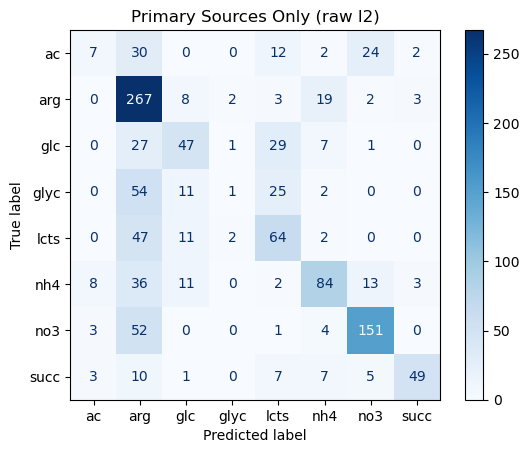

In [205]:
Y_pred_val_2 = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_source2, Y_pred_val_2)
disp = ConfusionMatrixDisplay(cm, display_labels=le_source2.classes_)

disp.plot(cmap='Blues')
plt.title("Primary Sources Only (raw l2)")
plt.show()

In [206]:
print(classification_report(
    Y_val_source2,
    Y_pred_val_2,
    target_names=le_source2.classes_
))

              precision    recall  f1-score   support

          ac       0.33      0.09      0.14        77
         arg       0.51      0.88      0.65       304
         glc       0.53      0.42      0.47       112
        glyc       0.17      0.01      0.02        93
        lcts       0.45      0.51      0.48       126
         nh4       0.66      0.54      0.59       157
         no3       0.77      0.72      0.74       211
        succ       0.86      0.60      0.71        82

    accuracy                           0.58      1162
   macro avg       0.53      0.47      0.47      1162
weighted avg       0.56      0.58      0.54      1162



### 1.2 - Testing different lables

*using log-transformed and L2-Normalized features, have tested for all source lables, and primary only*

1. Carbon vs Nitrogen source
2. Carbon and Nitrogen separate
3. Oxygen bin
4. PhPP phase?

**1. Carbon vs. Nitrogen**

In [224]:
Y_train_3 = Y_train['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'Nitrogen', False: 'Carbon'})
Y_val_3 = Y_val['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'Nitrogen', False: 'Carbon'})

le3 = LabelEncoder()
Y_train_bin = le3.fit_transform(Y_train_3)
Y_val_bin = le3.transform(Y_val_3)

In [225]:
base_clf.fit(X_train, Y_train_bin)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

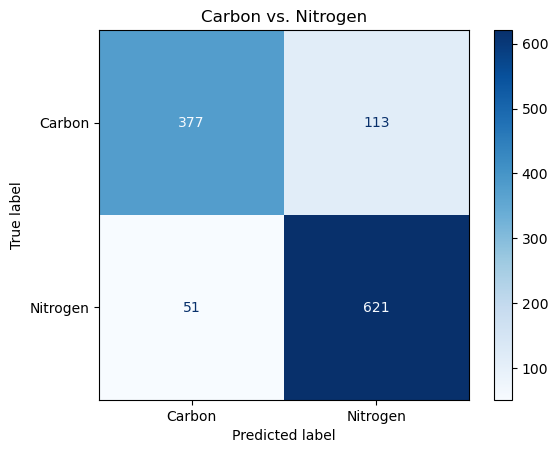

In [227]:
Y_pred_val_3 = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_bin, Y_pred_val_3)
disp = ConfusionMatrixDisplay(cm, display_labels=le3.classes_)

disp.plot(cmap='Blues')
plt.title("Carbon vs. Nitrogen")
plt.show()

In [229]:
accuracy = accuracy_score(Y_val_bin, Y_pred_val_3)
precision = precision_score(Y_val_bin, Y_pred_val_3)
recall = recall_score(Y_val_bin, Y_pred_val_3)
f1 = f1_score(Y_val_bin, Y_pred_val_3)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.859
Precision: 0.846
Recall:    0.924
F1-score:  0.883


***

**2. Carbon alone and Nitrogen alone**

In [249]:
X_train_c = X_train[Y_train_3 == 'Carbon']
X_val_c = X_val[Y_val_3 == 'Carbon']

Y_train_c = Y_train[Y_train_3 == 'Carbon']
Y_val_c = Y_val[Y_val_3 == 'Carbon']

#######################################################
X_train_n = X_train[Y_train_3 == 'Nitrogen']
X_val_n = X_val[Y_val_3 == 'Nitrogen']

Y_train_n = Y_train[Y_train_3 == 'Nitrogen']
Y_val_n = Y_val[Y_val_3 == 'Nitrogen']

In [250]:
Y_train_c = Y_train_c['source']
Y_val_c = Y_val_c['source']

le_c = LabelEncoder()

Y_train_enc_c = le_c.fit_transform(Y_train_c)
Y_val_enc_c = le_c.fit_transform(Y_val_c)

#########################################

le_n = LabelEncoder()

# Y_train_n = Y_train_n['source']
# Y_val_n = Y_val_n['source']
Y_train_n = Y_train_n['source'].str.split('_').str[0]
Y_val_n = Y_val_n['source'].str.split('_').str[0]

Y_train_enc_n = le_n.fit_transform(Y_train_n)
Y_val_enc_n = le_n.fit_transform(Y_val_n)

**CARBON**

In [238]:
base_clf.fit(X_train_c, Y_train_enc_c)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

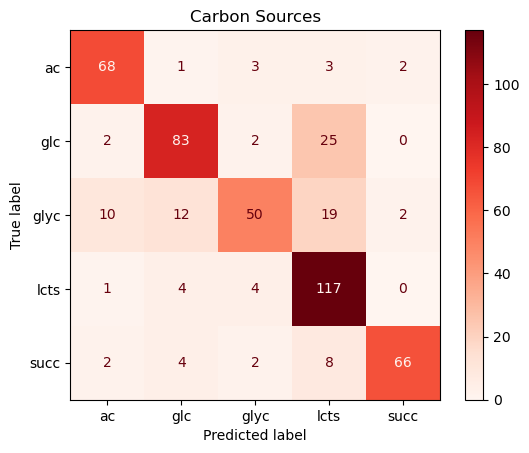

In [240]:
Y_pred_val_c = base_clf.predict(X_val_c)

cm = confusion_matrix(Y_val_enc_c, Y_pred_val_c)
disp = ConfusionMatrixDisplay(cm, display_labels=le_c.classes_)

disp.plot(cmap='Reds')
plt.title("Carbon Sources")
plt.show()

* enklere å skille acetat!

In [242]:
print(classification_report(
    Y_val_enc_c,
    Y_pred_val_c,
    target_names=le_c.classes_
))

              precision    recall  f1-score   support

          ac       0.82      0.88      0.85        77
         glc       0.80      0.74      0.77       112
        glyc       0.82      0.54      0.65        93
        lcts       0.68      0.93      0.79       126
        succ       0.94      0.80      0.87        82

    accuracy                           0.78       490
   macro avg       0.81      0.78      0.78       490
weighted avg       0.80      0.78      0.78       490



**NITROGEN**

In [251]:
base_clf.fit(X_train_n, Y_train_enc_n)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

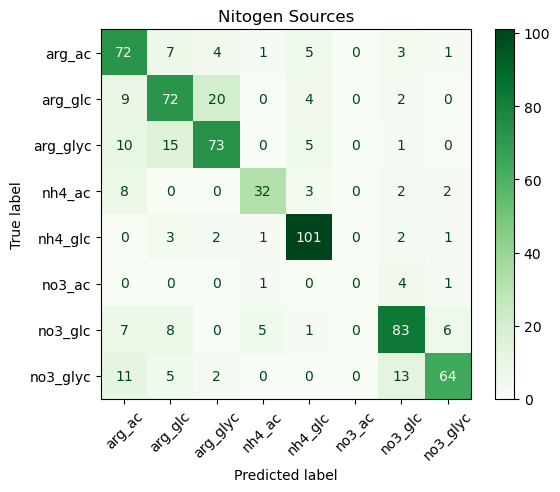

In [246]:
Y_pred_val_n = base_clf.predict(X_val_n)

cm = confusion_matrix(Y_val_enc_n, Y_pred_val_n)
disp = ConfusionMatrixDisplay(cm, display_labels=le_n.classes_)

disp.plot(cmap='Greens', xticks_rotation=45)
plt.title("Nitogen Sources")
plt.show()

In [247]:
print(classification_report(
    Y_val_enc_n,
    Y_pred_val_n,
    target_names=le_n.classes_
))

              precision    recall  f1-score   support

      arg_ac       0.62      0.77      0.69        93
     arg_glc       0.65      0.67      0.66       107
    arg_glyc       0.72      0.70      0.71       104
      nh4_ac       0.80      0.68      0.74        47
     nh4_glc       0.85      0.92      0.88       110
      no3_ac       0.00      0.00      0.00         6
     no3_glc       0.75      0.75      0.75       110
    no3_glyc       0.85      0.67      0.75        95

    accuracy                           0.74       672
   macro avg       0.66      0.65      0.65       672
weighted avg       0.74      0.74      0.74       672



/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

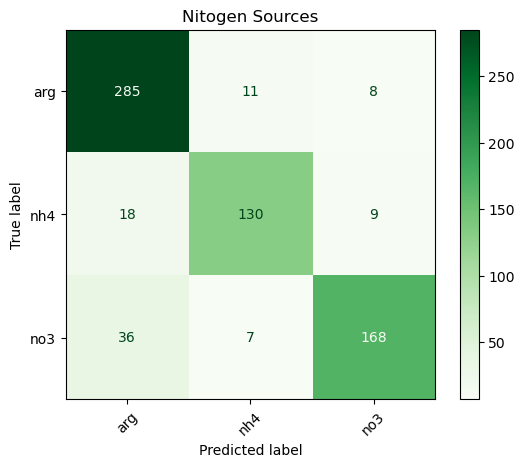

In [252]:
Y_pred_val_n = base_clf.predict(X_val_n)

cm = confusion_matrix(Y_val_enc_n, Y_pred_val_n)
disp = ConfusionMatrixDisplay(cm, display_labels=le_n.classes_)

disp.plot(cmap='Greens', xticks_rotation=45)
plt.title("Nitogen Sources")
plt.show()

In [253]:
print(classification_report(
    Y_val_enc_n,
    Y_pred_val_n,
    target_names=le_n.classes_
))

              precision    recall  f1-score   support

         arg       0.84      0.94      0.89       304
         nh4       0.88      0.83      0.85       157
         no3       0.91      0.80      0.85       211

    accuracy                           0.87       672
   macro avg       0.88      0.85      0.86       672
weighted avg       0.87      0.87      0.87       672



```text
Carbon vs nitrogen:

Accuracy:  0.859
Precision: 0.846
Recall:    0.924
F1-score:  0.883

***

**3. OXYGEN LEVELS**

In [265]:
bins = [0, 5, 10, 15, 25, 40, 60, 90, 135]
labels = ['0-5', '5-10', '10-15', '15-25', '25-40', '40-60', '60-90', '90-135']


Y_train['oxygen_bin'] = pd.cut(Y_train['EX_o2_e'], bins=bins, include_lowest=True, labels=labels, ordered=True)
Y_val['oxygen_bin'] = pd.cut(Y_val['EX_o2_e'], bins=bins, include_lowest=True, labels=labels, ordered=True)

#FIXING ORDER:

Y_train['oxygen_bin'] = pd.Categorical(
    pd.cut(Y_train['EX_o2_e'], bins=bins, labels=labels, include_lowest=True),
    categories=labels,
    ordered=True
)

Y_val['oxygen_bin'] = pd.Categorical(
    pd.cut(Y_val['EX_o2_e'], bins=bins, labels=labels, include_lowest=True),
    categories=labels,
    ordered=True
)

In [266]:
le_o2 = LabelEncoder()

Y_train_o2 = le_o2.fit_transform(Y_train['oxygen_bin'])
Y_val_o2 = le_o2.transform(Y_val['oxygen_bin'])

In [267]:
base_clf.fit(X_train, Y_train_o2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

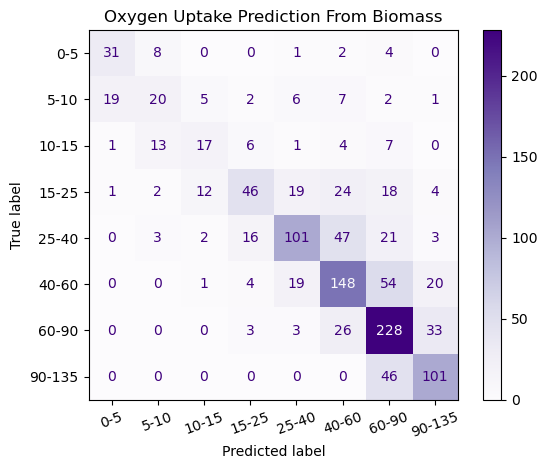

In [291]:
Y_pred_val_o2 = base_clf.predict(X_val)

cm = confusion_matrix(Y_val_o2, Y_pred_val_o2)

idx = [list(le_o2.classes_).index(c) for c in labels]
cm_reordered = cm[np.ix_(idx, idx)]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_reordered, display_labels=labels)

disp.plot(cmap='Purples', xticks_rotation=20)
plt.title("Oxygen Uptake Prediction From Biomass")
plt.show()

In [283]:
print(classification_report(
    Y_val_o2,
    Y_pred_val_o2,
    target_names=le_o2.classes_
))

              precision    recall  f1-score   support

         0-5       0.60      0.67      0.63        46
       10-15       0.46      0.35      0.40        49
       15-25       0.60      0.37      0.45       126
       25-40       0.67      0.52      0.59       193
       40-60       0.57      0.60      0.59       246
        5-10       0.43      0.32      0.37        62
       60-90       0.60      0.78      0.68       293
      90-135       0.62      0.69      0.65       147

    accuracy                           0.60      1162
   macro avg       0.57      0.54      0.54      1162
weighted avg       0.59      0.60      0.59      1162



***

## 2. Multioutput or not?

*if i want the classifier to predict more than one target for each sample at a time*

In [314]:
Y_train_ex = Y_train.iloc[:, 3:]
Y_val_ex = Y_val.iloc[:, 3:]

Y_train_act = (Y_train_ex != 0).astype(int)
Y_val_act   = (Y_val_ex != 0).astype(int)

In [316]:
multi_clf.fit(X_train, Y_train_act)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,RandomForestC...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the fol

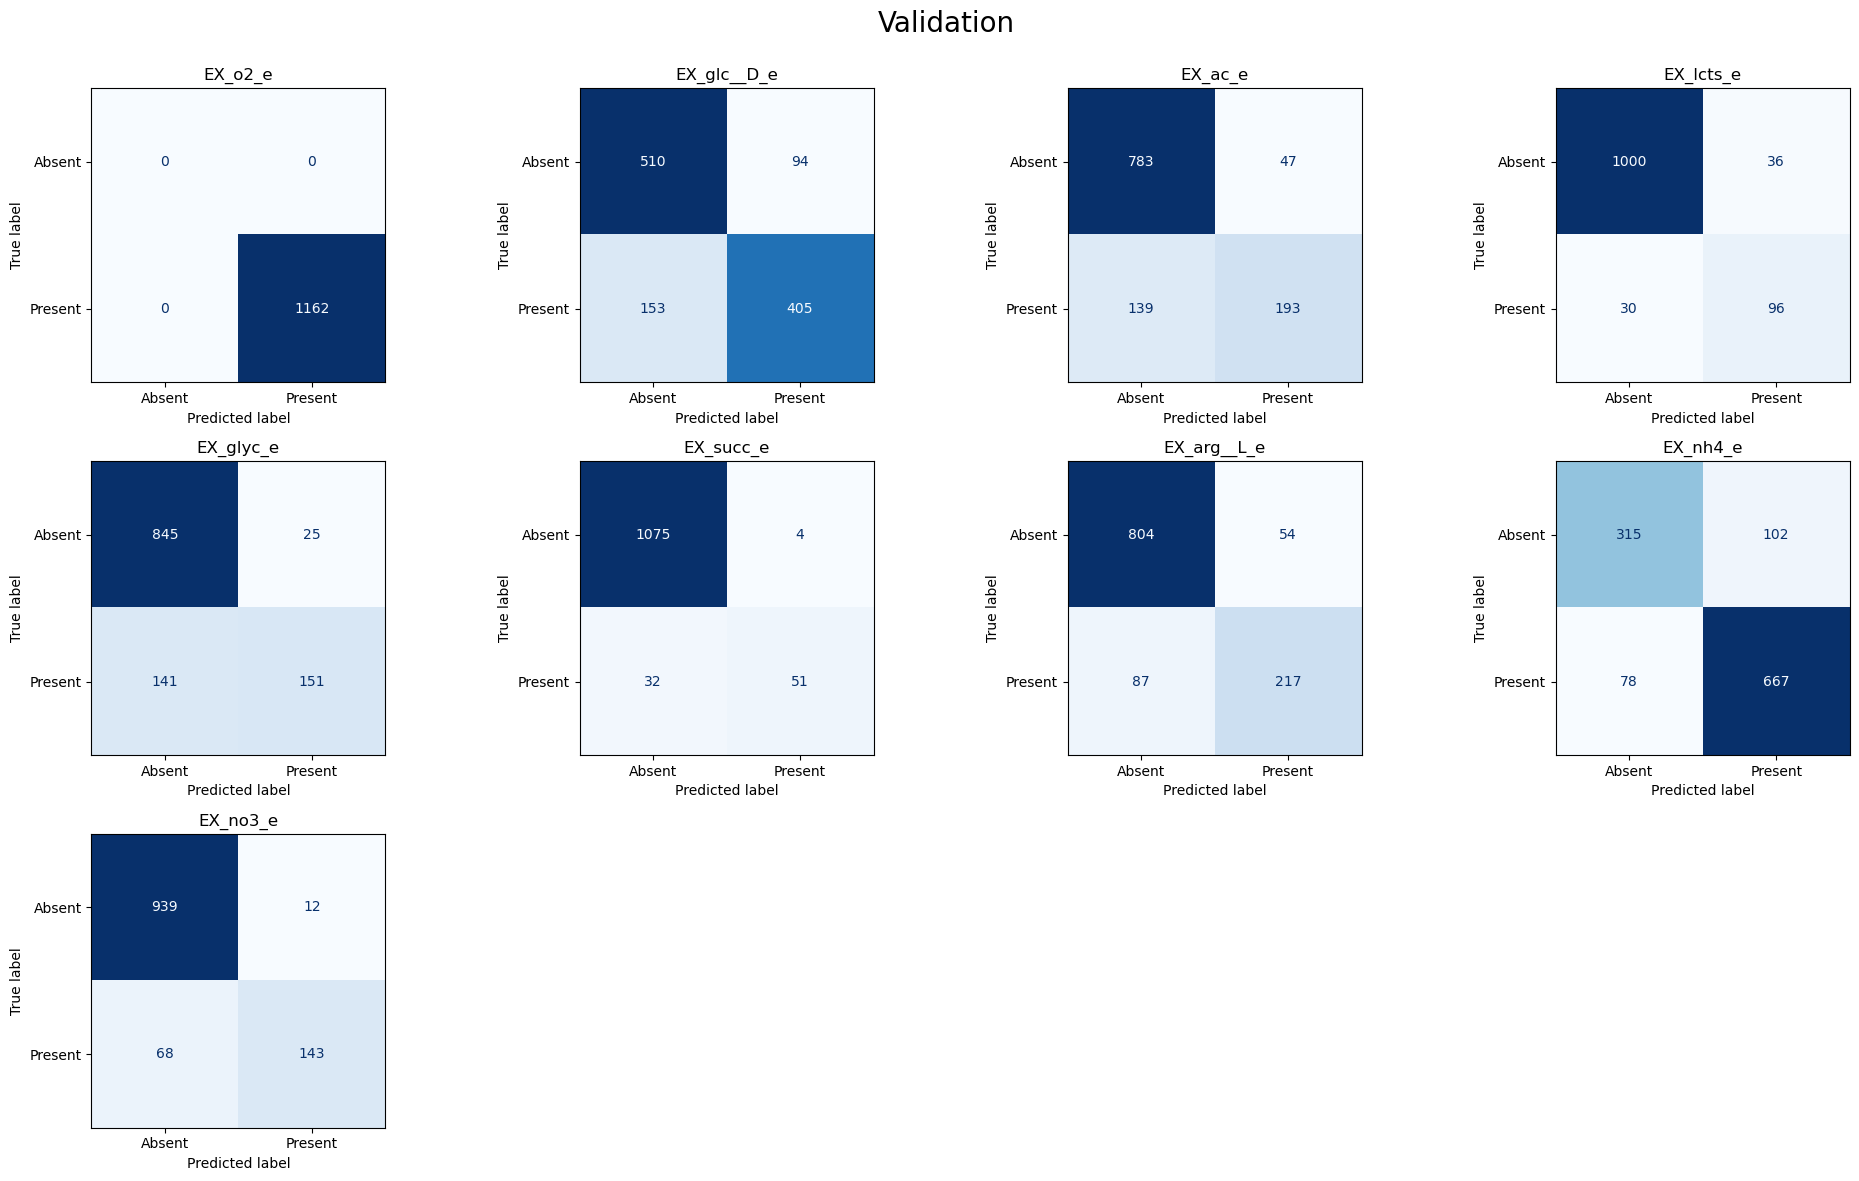

In [317]:
Y_pred_val = multi_clf.predict(X_val)

n_targets = Y_train_act.shape[1]

# Choose grid size (auto)
n_cols = 4
n_rows = int(np.ceil(n_targets / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.ravel()

for i, col in enumerate(Y_train_act.columns):
    cm = confusion_matrix(
        Y_val_act.iloc[:, i],
        Y_pred_val[:, i],
        labels=[0, 1] 
    )
    
    disp = ConfusionMatrixDisplay(cm, display_labels=['Absent', 'Present'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    
    # Optional: add class balance info
    n_pos = Y_val_act.iloc[:, i].sum()
    n_total = len(Y_val_act)
    axes[i].set_title(f"{col}")

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Validation", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

* ser at konsekvensene for falsk negativ er store, dette er også en vanskeligere task
* for each sample, if the predictor is unsure, it is for most easier to just assume that the target is absent (since it most likely is)

In [320]:
Y_pred_val = multi_clf.predict(X_val)

clf_results = []
for i, col in enumerate(Y_val_act.columns):
    y_true = Y_val_act.iloc[:, i]
    y_pred = Y_pred_val[:, i]
    
    clf_results.append({
        'Target': col,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    })

df_results = pd.DataFrame(clf_results)
df_results

,Target,Accuracy,Precision,Recall,F1 Score
0,EX_o2_e,1.000000,1.000000,1.000000,1.000000
1,EX_glc__D_e,0.787435,0.811623,0.725806,0.766320
2,EX_ac_e,0.839931,0.804167,0.581325,0.674825
3,EX_lcts_e,0.943201,0.727273,0.761905,0.744186
4,EX_glyc_e,0.857143,0.857955,0.517123,0.645299
5,EX_succ_e,0.969019,0.927273,0.614458,0.739130
6,EX_arg__L_e,0.878657,0.800738,0.713816,0.754783
7,EX_nh4_e,0.845095,0.867360,0.895302,0.881110
8,EX_no3_e,0.931153,0.922581,0.677725,0.781421
